# E-Commerce Logistics Pipeline: Olist Brazil

### Project Scoping & Business Understanding

Este proyecto utiliza el dataset público de Olist (el mercado virtual más grande de Brasil).
Con el objetivo de analizar el desempeño logistico de Olist.

## 1. Objetivos del Proyecto & Contexto de Negocio
* **Problema:** Alta tasa de órdenes con retrasos
* **Objetivo Técnico:** Diseñar un pipeline ETL robusto para centralizar datos logísticos.
* **Impacto de Negocio:** Permitir que se tomen decisiones logisitcas para reducir los retrasos usando un dashboar, a fin de aumentar la satisfaccion en el cliente e incrementar las ventas

At the end, we will see:
- Time mean of delivery (tiempo promedio de entrega)
- Process bottlenecks
- Sellers con mayor proporcion de retrasos
- Categorias con mayores tiempos de entrega
- Impact de los retrasos en la satisfaccion del cliente
- Oportunidades de mejoras

---

**This project will solve the questions below:**

¿Cuánto demora cada pedido?

¿Qué etapa genera mas demora? (from approved_at to delivered_customer)

¿Qué porcentaje de pedidos se entregan después de la fecha estimada?

¿Cuáles son los vendedores con mayor índice de entregas tardías?

¿En que estados se encuentran los vendedores con mayor indice de entregas tardias?

¿Qué categorias generan el mayor indice de entregas tardias?

¿Cual es la causa de la demora en la entrega? (Sellers, categorias, geografia)

¿La demora afecta las calificaciones?

¿Cómo se pueden solucionar las demoras?

¿Qué beneficios traeria disminuir las demoras?

---

## 2. Data Source

**Olist E-Comerce Dataset**

**Tables:**

* olist_customers_dataset.csv
* olist_geolocation_dataset.csv
* olist_order_items_dataset.csv
* olist_order_payments_dataset.csv
* olist_order_reviews_dataset.csv
* olist_orders_dataset.csv
* olist_products_dataset.csv
* olist_sellers_dataset.csv
* product_category_name_translation.csv

---

### 3. Pipeline Architecture & Data Flow

1. **Source & Ingestion:** The project starts with 9 relational CSV datasets from Olist located in `data/raw/`. A Python script loads them as raw tables into a local **PostgreSQL** instance running inside a Docker container, simulating a production OLTP database.
2. **Medallion Architecture (Local Lakehouse):** All files are mapped to the local host machine using Docker Bind Mount Volumes to ensure data persistence.
   * **Bronze Layer:** Data is queried from PostgreSQL via SQL (`extract.py`) and stored in Parquet format within `data/bronze/`.
   * **Silver Layer:** Python and **Pandas** clean the data (`transform.py`), handling missing values in delivery dates and enforcing strict data types based on the EDA findings.
   * **Gold Layer:** Cleansed data is enriched, joined, and aggregated into business-oriented tables optimized for analytical purposes.
3. **Orchestration & Governance:** **Apache Airflow** manages the entire end-to-end workflow from inside Docker. It ensures task dependencies are met, captures operational logs, triggers automatic retries upon failure, and sends alerts if critical errors occur.
4. **Cloud Analytics & BI:** The finalized Gold tables are uploaded to **Google BigQuery** (`load.py`). Finally, **Power BI** connects to BigQuery to serve interactive dashboards for business stakeholders.

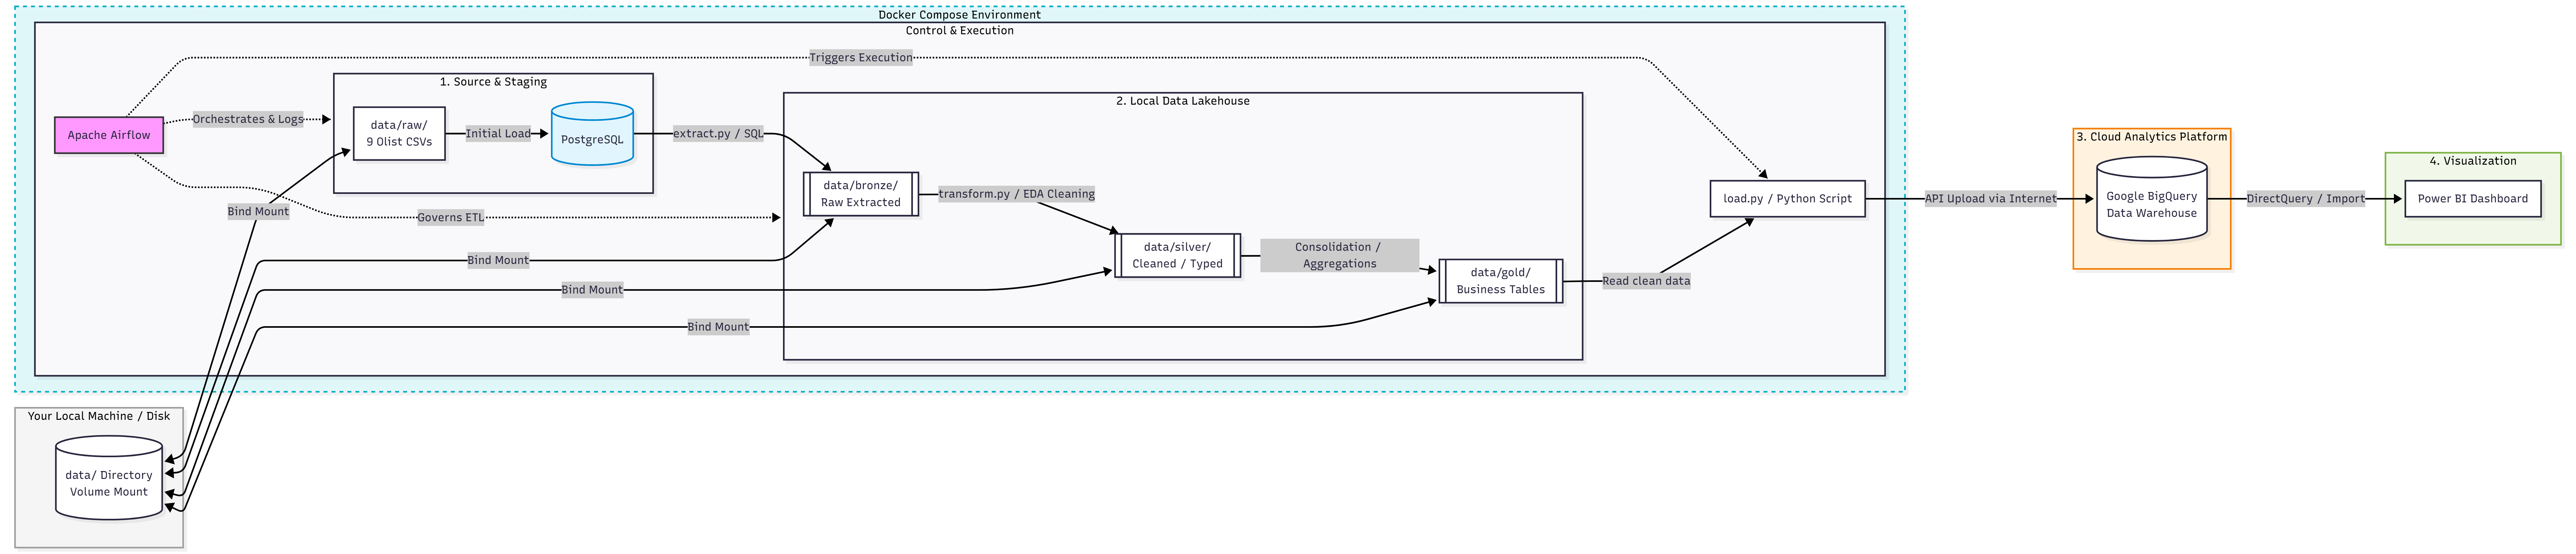

---

### 4. STACK:
* PYTHON
* PANDAS
* POSTGRESQL
* AIRFLOW
* BIGQUERY
* POWER BI
* DOCKER
* GIT
